# Pre-processing data

In [177]:
#Import libraries 
%matplotlib inline
#
# data manipulation and math
#
import numpy as np
import scipy as sp
import pandas as pd
#
# plotting and visualization
#
import matplotlib as mpl
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
#
import seaborn as sns
#
# modeling -
#
from sklearn.preprocessing import OneHotEncoder as OHE
import sklearn.model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
#
plt.rcParams['figure.figsize'] = (3, 3)
plt.style.use('seaborn-v0_8-pastel')   # updated style name
plt.rcParams['figure.dpi'] = 150      
#
c0 = sns.color_palette()[0]
c1 = sns.color_palette()[1]
c2 = sns.color_palette()[2]
#
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])
cm = plt.cm.RdBu
cm_bright = ListedColormap(['#FF0000', '#0000FF'])

In [5]:
def points_plot(ax, Xtr, Xte, ytr, yte, 
                clf, 
                mesh = True, colorscale = cmap_light, cdiscrete = cmap_bold, 
                alpha = 0.1, psize = 10, 
                zfunc = False, predicted = False):
#
# note: this function only works for X.shape = (:, 2)
# it is intended to illustrate the classifier boundary
#
# get the column names if they exist to apply
# to the meshed data generated below
#
    try:
        feature_names = Xtr.columns
    except:
        feature_names = None
#        
    Xtrain = np.array(Xtr)
    Xtest = np.array(Xte)
#
    h = 0.02
#
# create a uniform grid spanning the range of the X values
# note that y here is NOT the target, it is the 2nd
# dimension of the desired plot
#
    X = np.concatenate((Xtrain, Xtest))
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
#
# predict the target value at each point in the grid
#
# this method uses the probabilities from the classifier
# and applies a function to determine the class
#
    if zfunc:
        mesh_data = np.c_[xx.ravel(), yy.ravel()]
        if feature_names is not None:
            mesh_data = pd.DataFrame(mesh_data, 
                         columns = feature_names)
        p0 = clf.predict_proba(mesh_data)[:, 0]
        p1 = clf.predict_proba(mesh_data)[:, 1]
        Z = zfunc(p0, p1)
#
# this method uses the classifier to predict the classes directly
#
    else:
        mesh_data = np.c_[xx.ravel(), yy.ravel()]
        if feature_names is not None:
            mesh_data = pd.DataFrame(mesh_data, 
                                     columns = feature_names)
        Z = clf.predict(mesh_data)
    ZZ = Z.reshape(xx.shape)
#
# plt.pcolormesh() creates a shaded result over the grid
#
    if mesh:
        plt.pcolormesh(xx, yy, ZZ, 
                       cmap = cmap_light, 
                       alpha = alpha, 
                       axes = ax, 
                       shading = 'auto')
#
# add the points to the plot
# these can be the original target values
# or the predicted values
#
    if predicted:
        showtr = clf.predict(Xtr)
        showte = clf.predict(Xte)
    else:
        showtr = ytr
        showte = yte
#
# plot training points
#
    ax.scatter(Xtrain[:, 0], Xtrain[:, 1], 
               c = showtr - 1, 
               cmap = cmap_bold, 
               s = psize, 
               alpha = alpha, 
               edgecolor = "k")
#    
# plot testing points
#
    ax.scatter(Xtest[:, 0], Xtest[:, 1],
               c = showte - 1, 
               cmap = cmap_bold, 
               s = psize + 10,
               alpha = alpha, 
               marker = "s")
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
#
    return ax, xx, yy

In [6]:
def points_plot_prob(ax, Xtr, Xte, ytr, yte, 
                     clf, colorscale = cmap_light, cdiscrete = cmap_bold, 
                     ccolor = cm, 
                     alpha = 0.1, psize = 10):
    try:
        feature_names = Xtr.columns
    except:
        feature_names = None
#        
    Xtrain = np.array(Xtr)
    Xtest = np.array(Xte)
#    
    ax, xx, yy = points_plot(ax, Xtr, Xte, ytr, yte,
                         clf,
                         mesh = False, 
                         colorscale = colorscale, cdiscrete = cdiscrete, 
                         psize = psize, alpha = alpha,
                         predicted = True) 
    mesh_data = np.c_[xx.ravel(), yy.ravel()]
    if feature_names is not None:
        mesh_data = pd.DataFrame(mesh_data, 
                     columns = feature_names)    
    Z = clf.predict_proba(mesh_data)[:, 1]
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap = ccolor, alpha = 0.2)
    cs2 = plt.contour(xx, yy, Z, cmap = ccolor, alpha = 0.6)
    plt.clabel(cs2, fmt = '%2.1f', colors = 'k', fontsize = 12)
#
    plt.show()

In [7]:
#Import the clean dataset 
df=pd.read_csv(r"../data/brfss_2021_clean.csv")

In [8]:
#Review the first few rows
df.head()

,_STATE,PERSDOC3,_RFHYPE6,MARITAL,EMPLOY1,_METSTAT,_URBSTAT,_RFHLTH,_PHYS14D,_HLTHPLN,_TOTINDA,_RACE,_SEX,_AGEG5YR,_AGE80,_BMI5,_BMI5CAT,_EDUCAG,_INCOMG1,_SMOKER3,_CURECI1,DRNKANY5,_FRUTSU1,_VEGESU1,GRENDA1_,FRNCHDA_,_PHYS14D_missing,_RACE_missing,_HLTHPLN_missing,_CURECI1_missing,_SMOKER3_missing,DRNKANY5_missing,GRENDA1__missing,FRNCHDA__missing,_FRUTSU1_missing,_VEGESU1_missing,_BMI5_missing,INCOME_GROUP,HIGHBP
0,1.0,1.0,0.0,1.0,7.0,1.0,1.0,2.0,3.0,1.0,2.0,1.0,2.0,11.0,70.0,14.54,1.0,2.0,3.0,3.0,1.0,2.0,1.00,2.14,0.57,0.43,0,0,0,0,0,0,0,0,0,0,0,Low,0
1,1.0,2.0,1.0,1.0,8.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,10.0,67.0,27.44,NaN,4.0,NaN,4.0,1.0,2.0,1.00,1.28,0.14,0.00,0,0,0,0,0,0,0,0,0,0,1,Missing,1
2,1.0,2.0,1.0,3.0,7.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,11.0,72.0,28.29,3.0,2.0,2.0,4.0,1.0,2.0,1.00,0.71,0.00,0.14,0,0,0,0,0,0,0,0,0,0,0,Low,1
3,1.0,1.0,1.0,1.0,7.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,NaN,62.0,33.47,4.0,2.0,5.0,4.0,1.0,1.0,1.14,1.65,0.10,0.57,0,0,0,0,0,0,0,0,0,0,0,Medium,1
4,1.0,1.0,0.0,1.0,8.0,2.0,1.0,2.0,3.0,1.0,1.0,7.0,1.0,12.0,76.0,28.73,3.0,1.0,2.0,4.0,1.0,2.0,1.00,2.58,1.00,0.29,0,0,0,0,0,0,0,0,0,0,0,Low,0


In [10]:
df.shape

(436781, 39)

In [22]:
#Measure class counts for Hypertension (target variable)
class_counts = df['HIGHBP'].value_counts()
class_counts

HIGHBP
0    264648
1    172133
Name: count, dtype: int64

In [23]:
#Convert to percentages for better visualization 
class_percentages = pd.Series([(x / df.shape[0]) * 100.00 for x in class_counts])
class_percentages

0    60.590548
1    39.409452
dtype: float64

Note - We can observe the imbalance in the two classes so we can justify stratifying by the target variable when we will split the data into training and testing.

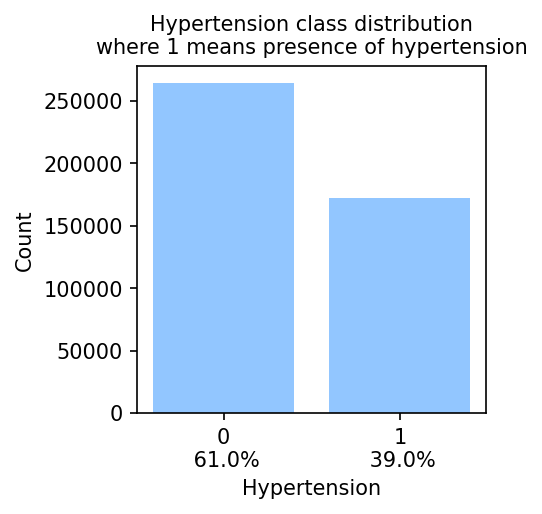

In [46]:
#Plot the target variable 
fig, ax = plt.subplots()
ax.bar(class_counts.index, class_counts)
ax.set_xticks([0, 1])
ax.set_xticklabels(class_percentages.index.astype(str) + '\n' + ' ' +
                   class_percentages.round(0).astype(str) + '%')
ax.set_ylabel('Count')
ax.set_xlabel('Hypertension')
ax.set_title('Hypertension class distribution\nwhere 1 means presence of hypertension',
              fontsize = 10)
plt.show()

Based on my observations from the data wrangling and EDA, I will drop:

1. HIGHBP - this is your target variable, not a predictor. Will not be included in the features 
2. _RFHYPE6 - this is original hypertension variable. We have HIGHBP as the binary variable 
3. GRENDA1_ - showed moderate correlation with other diet variable and would be redundant 
4. DRNKANY5 - EDA showed some doubts about the truthfullness of the responses  
5. GRENDA1__missing
6. DRNKANY5_missing
7. _AGEG5YR - keeping the continous variable _AGE80 as it has no missing values 
8. _BMI5CAT - keeping the continous variable _BMI5 as it has no missing values 
9. _INCOMG1 - since I created INCOME_GROUP
10. _STATE - will create too many dummy variables and reduce interpretability|

In [12]:
#Target variable
y = df['HIGHBP']

#Features
X = df.drop(columns=[
    'HIGHBP',
    '_RFHYPE6',
    'GRENDA1_',
    'GRENDA1__missing',
    'DRNKANY5',
    'DRNKANY5_missing',
    '_AGEG5YR',
    '_BMI5CAT',
    '_INCOMG1', 
    '_STATE'
])

In [13]:
print(X.shape)
print(y.shape)

(436781, 29)
(436781,)


In [14]:
#Split all the features into categorical, numerical, missing indicator 
categorical_features = [
    'PERSDOC3',
    'MARITAL',
    'EMPLOY1',
    '_METSTAT',
    '_URBSTAT',
    '_RFHLTH',
    '_HLTHPLN',
    '_TOTINDA',
    '_RACE',
    '_SEX',
    '_EDUCAG',
    '_SMOKER3',
    '_CURECI1',
    'INCOME_GROUP'
]

numerical_features = [
    '_AGE80',
    '_BMI5',
    '_PHYS14D',
    '_FRUTSU1',
    '_VEGESU1',
    'FRNCHDA_'
]

#Missing indicator features are already binary 
missing_indicator_features = [
    '_PHYS14D_missing',
    '_RACE_missing',
    '_HLTHPLN_missing',
    '_CURECI1_missing',
    '_SMOKER3_missing',
    'FRNCHDA__missing',
    '_FRUTSU1_missing',
    '_VEGESU1_missing',
    '_BMI5_missing'
]

In [15]:
#Use one-hot encoding to create dummy variables for all categorical variables
X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

In [16]:
print("Shape after one-hot encoding:", X.shape)

Shape after one-hot encoding: (436781, 53)


In [17]:
#Split the data into train/test 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y #Stratifying to correct for class imbalance 
)

In [18]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (349424, 53)
Testing set: (87357, 53)


In [19]:
#Check class balance 
print("Training Set Class Distribution")
print(y_train.value_counts(normalize=True))

print("\nTesting Set Class Distribution")
print(y_test.value_counts(normalize=True))

Training Set Class Distribution
HIGHBP
0    0.605906
1    0.394094
Name: proportion, dtype: float64

Testing Set Class Distribution
HIGHBP
0    0.605905
1    0.394095
Name: proportion, dtype: float64


In [60]:
#Plot class balance
def plot_y_ratios(y, ytest):
    fig, ax = plt.subplots(2, sharex = True)
    ax[0].bar(x = [0, 1], height = [y[y == 0].count(), 
                                    y[y == 1].count()])
    ax[0].set_ylabel('train', fontsize = 8)
    ax[0].set_ylim(0, 125)
    ax[1].bar(x = [0, 1], height = [ytest[ytest == 0].count(),
                                    ytest[ytest == 1].count()])
    ax[1].set_ylabel('test', fontsize = 8)
    ax[1].set_ylim(0, 125)
    ax[1].set_xticks([0, 1])
    ax[0].tick_params(which = 'both', labelsize = 8)
    ax[1].tick_params(which = 'both', labelsize = 8)
    ax[1].set_xlabel('hypertension\n(0 = no high bp)', fontsize = 8)
    ax[0].set_title('% hypertension (where 1 means presence of high bp):\n' +
                    'train: ' + str(round(100 * (y[y ==1].count()/y.shape[0]), 0)) +
                    '\ntest: ' + str(round(100 * (ytest[ytest ==1].count()/ytest.shape[0]), 0)),
                   fontsize = 10)
    plt.show() 

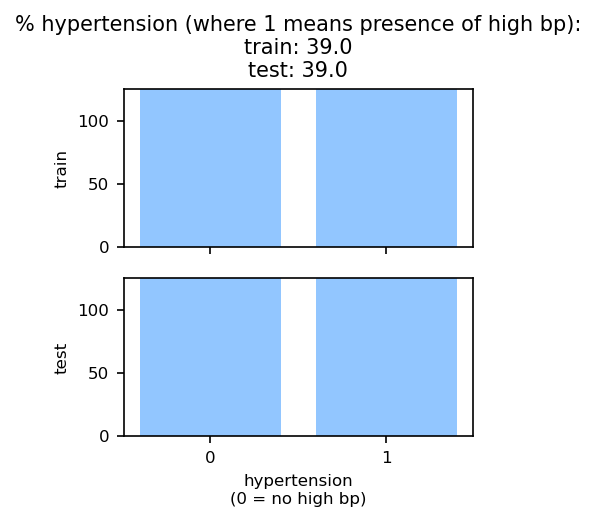

In [64]:
plot_y_ratios(y_train, y_test)

Note - we can see that the target variable is now properly balanced between training and test data. 

In [20]:
#Standardize the numerical variables for the training data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

X_test[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

In [21]:
#Check if the standardization worked 
print(X_train[numerical_features].describe().round(2))

          _AGE80      _BMI5   _PHYS14D   _FRUTSU1   _VEGESU1   FRNCHDA_
count  349424.00  349424.00  349424.00  349424.00  349424.00  349424.00
mean        0.00      -0.00       0.00      -0.00      -0.00      -0.00
std         1.00       1.00       1.00       1.00       1.00       1.00
min        -2.09      -2.70      -0.63      -1.19      -1.47      -0.76
25%        -0.78      -0.66      -0.63      -0.65      -0.50      -0.50
50%         0.13      -0.16      -0.63      -0.27      -0.18      -0.23
75%         0.81       0.43       0.81       0.65       0.23       0.34
max         1.44       6.82       2.25       8.01      10.37      10.61


# Modeling

A. Objective - The objective of this notebook is to develop and compare several supervised machine learning models to predict the presence of hyptertension using demographic, socioeconomic, behavioral, lifestyle, and nutrition-related variables collected through the 2021 Behavioral Risk Factor Surveillance System (BRFSS).

B. Models - I will be using three models for evaluation and comparison:

1. Logistic regression - This establishes a simple baseline model as it is easily interpretable.
2. Decision tree - This captures non-linear relationships and is also easy to visualize and interpret
3. Random forest - This is the ensemble version of the Decision trees, reduces overfitting, and can produce better predictive performance.

C. Evaluation metrics - Models will be compared using multiple evaluation metrics:
1. Accuracy - measures the proportion of correctly classified observations
2. Precision - among observations predicted as hypertensive, how many actually had hypertension
3. Recall (Senstivity) - Among individuals who truly have hypertension, how many were correctly identified. This is important in healthcare because missing high-risk patients may delay intervention
4. F1 score - Balances precision and recall.
5. ROC-AUC - Measures how well the model discriminates between hypertensive and non-hypertensive individuals across all possible classification thresholds
   
D. Hyperparamter tuning - The Decision Tree and Random Forest models will first be trained using default parameters to establish a baseline. Hyperparameter tuning using GridSearchCV or RandomizedGridSearch will then be performed to optimize model performance. The Logistic Regression Model will be trained using the default parameters to establish a baseline but no hyperparameter tuning will be performed. 

In [50]:
print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

print("Number of predictors:", X_train.shape[1])

print("\nTraining prevalence of hypertension:")
print(y_train.value_counts(normalize=True))

Training observations: 349424
Testing observations: 87357
Number of predictors: 53

Training prevalence of hypertension:
HIGHBP
0    0.605906
1    0.394094
Name: proportion, dtype: float64


# 1.0 Baseline Model: Logistic Regression 

In [68]:
#Initiate the baseline Logistic Regression model
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_reg.fit(X_train, y_train) 

LogisticRegression(max_iter=1000, random_state=42)

In [70]:
#Class predictions
y_pred_lr = log_reg.predict(X_test)

#Predicted probabilities
y_prob_lr = log_reg.predict_proba(X_test)[:,1]

In [84]:
#Evaluate the model 
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print(f"Accuracy : {lr_accuracy:.3f}")
print(f"Precision: {lr_precision:.3f}")
print(f"Recall   : {lr_recall:.3f}")
print(f"F1 Score : {lr_f1:.3f}")
print(f"ROC-AUC  : {lr_auc:.3f}")

Accuracy : 0.720
Precision: 0.662
Recall   : 0.590
F1 Score : 0.624
ROC-AUC  : 0.786


In [88]:
#Print the classification report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.75      0.80      0.78     52930
           1       0.66      0.59      0.62     34427

    accuracy                           0.72     87357
   macro avg       0.71      0.70      0.70     87357
weighted avg       0.72      0.72      0.72     87357



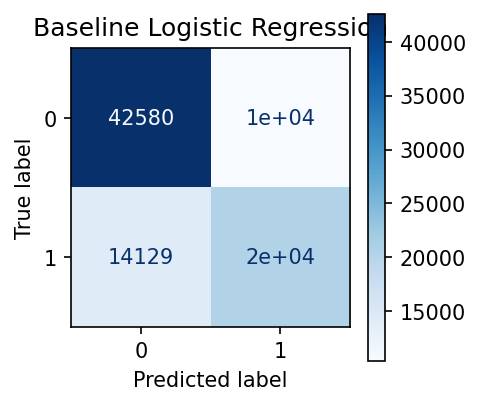

In [90]:
#Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    cmap="Blues"
)

plt.title("Baseline Logistic Regression")
plt.show()

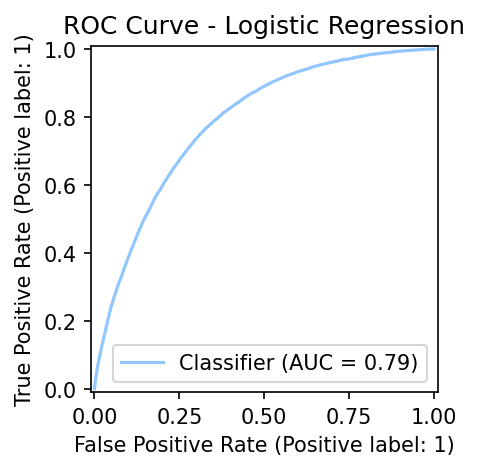

In [92]:
#Plot the ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

Observations from the baseline logistic regression model

1. Accuracy - 72% of the respondents were classified correctly
2. Precision - When the model predicts hypertension, it is correct 66% of the time
3. Recall - The model identifies 59% if the people who actually have hypertension. This means that out of 10 individuals, it will correctly identify 6 hypertensive individuals. However, 41% of the hypertensive individuals will be missed (false negatives)
4. F1 Score - 62% balance between precision and recall
5. ROC-AUC - at around 79% which is acceptable/good discrimination between hypertensive and non-hypertensive individuals.

Overall, this is a reasonably strong baseline. Although Logistic Regression assumes a linear relationship between the predictors and the log-odds of hypertension, these results demonstrate that demographic, socioeconomic, behavioral, and nutritional variables contain meaningful predictive information. This model serves as an interpretable benchmark against which more flexible machine learning algorithms will be compared. Although Logistic Regression supports hyperparameter tuning, the expected gains are generally modest relative to the non-linear, tree-based methods. Therefore, the baseline model is retained as the reference model, while hyperparameter tuning is reserved for the Decision Tree and Random Forest models where hyperparameter tuning is expected to have a greater impact on predictive performance.

# 2.0 Baseline Decision Tree 

In [108]:
#Initiate the baseline Decision Tree model 
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [110]:
#Class predictions
y_pred_dt = dt.predict(X_test)

#Predicted probabilities
y_prob_dt = dt.predict_proba(X_test)[:,1]

In [112]:
#Evaluate the model
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_auc = roc_auc_score(y_test, y_prob_dt)

print(f"Accuracy : {dt_accuracy:.3f}")
print(f"Precision: {dt_precision:.3f}")
print(f"Recall   : {dt_recall:.3f}")
print(f"F1 Score : {dt_f1:.3f}")
print(f"ROC-AUC  : {dt_auc:.3f}")

Accuracy : 0.632
Precision: 0.533
Recall   : 0.538
F1 Score : 0.535
ROC-AUC  : 0.615


In [115]:
#Print the classification report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.70      0.69      0.70     52930
           1       0.53      0.54      0.54     34427

    accuracy                           0.63     87357
   macro avg       0.62      0.62      0.62     87357
weighted avg       0.63      0.63      0.63     87357



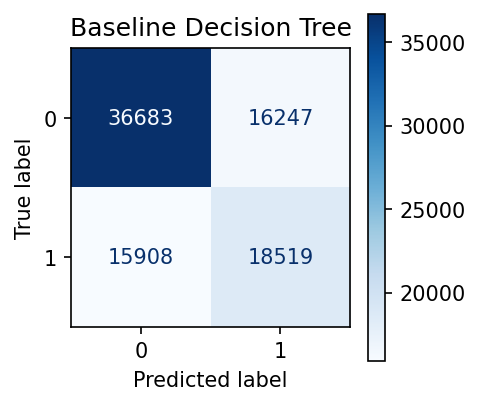

In [256]:
#Plot the confusion matrix 
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    cmap="Blues"
)

plt.title("Baseline Decision Tree")
plt.show()

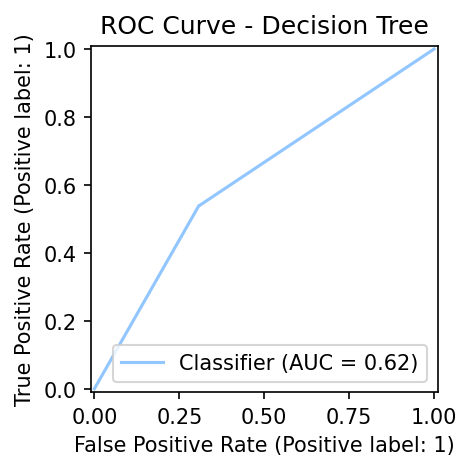

In [121]:
#Plot the ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_dt
)

plt.title("ROC Curve - Decision Tree")
plt.show()

In [123]:
#Measure the extent of overfitting by looking at the accuracy of training and testing
train_pred_dt = dt.predict(X_train)

train_accuracy_dt = accuracy_score(y_train, train_pred_dt)

print(f"Training Accuracy: {train_accuracy_dt:.3f}")
print(f"Testing Accuracy : {dt_accuracy:.3f}")

Training Accuracy: 0.999
Testing Accuracy : 0.632


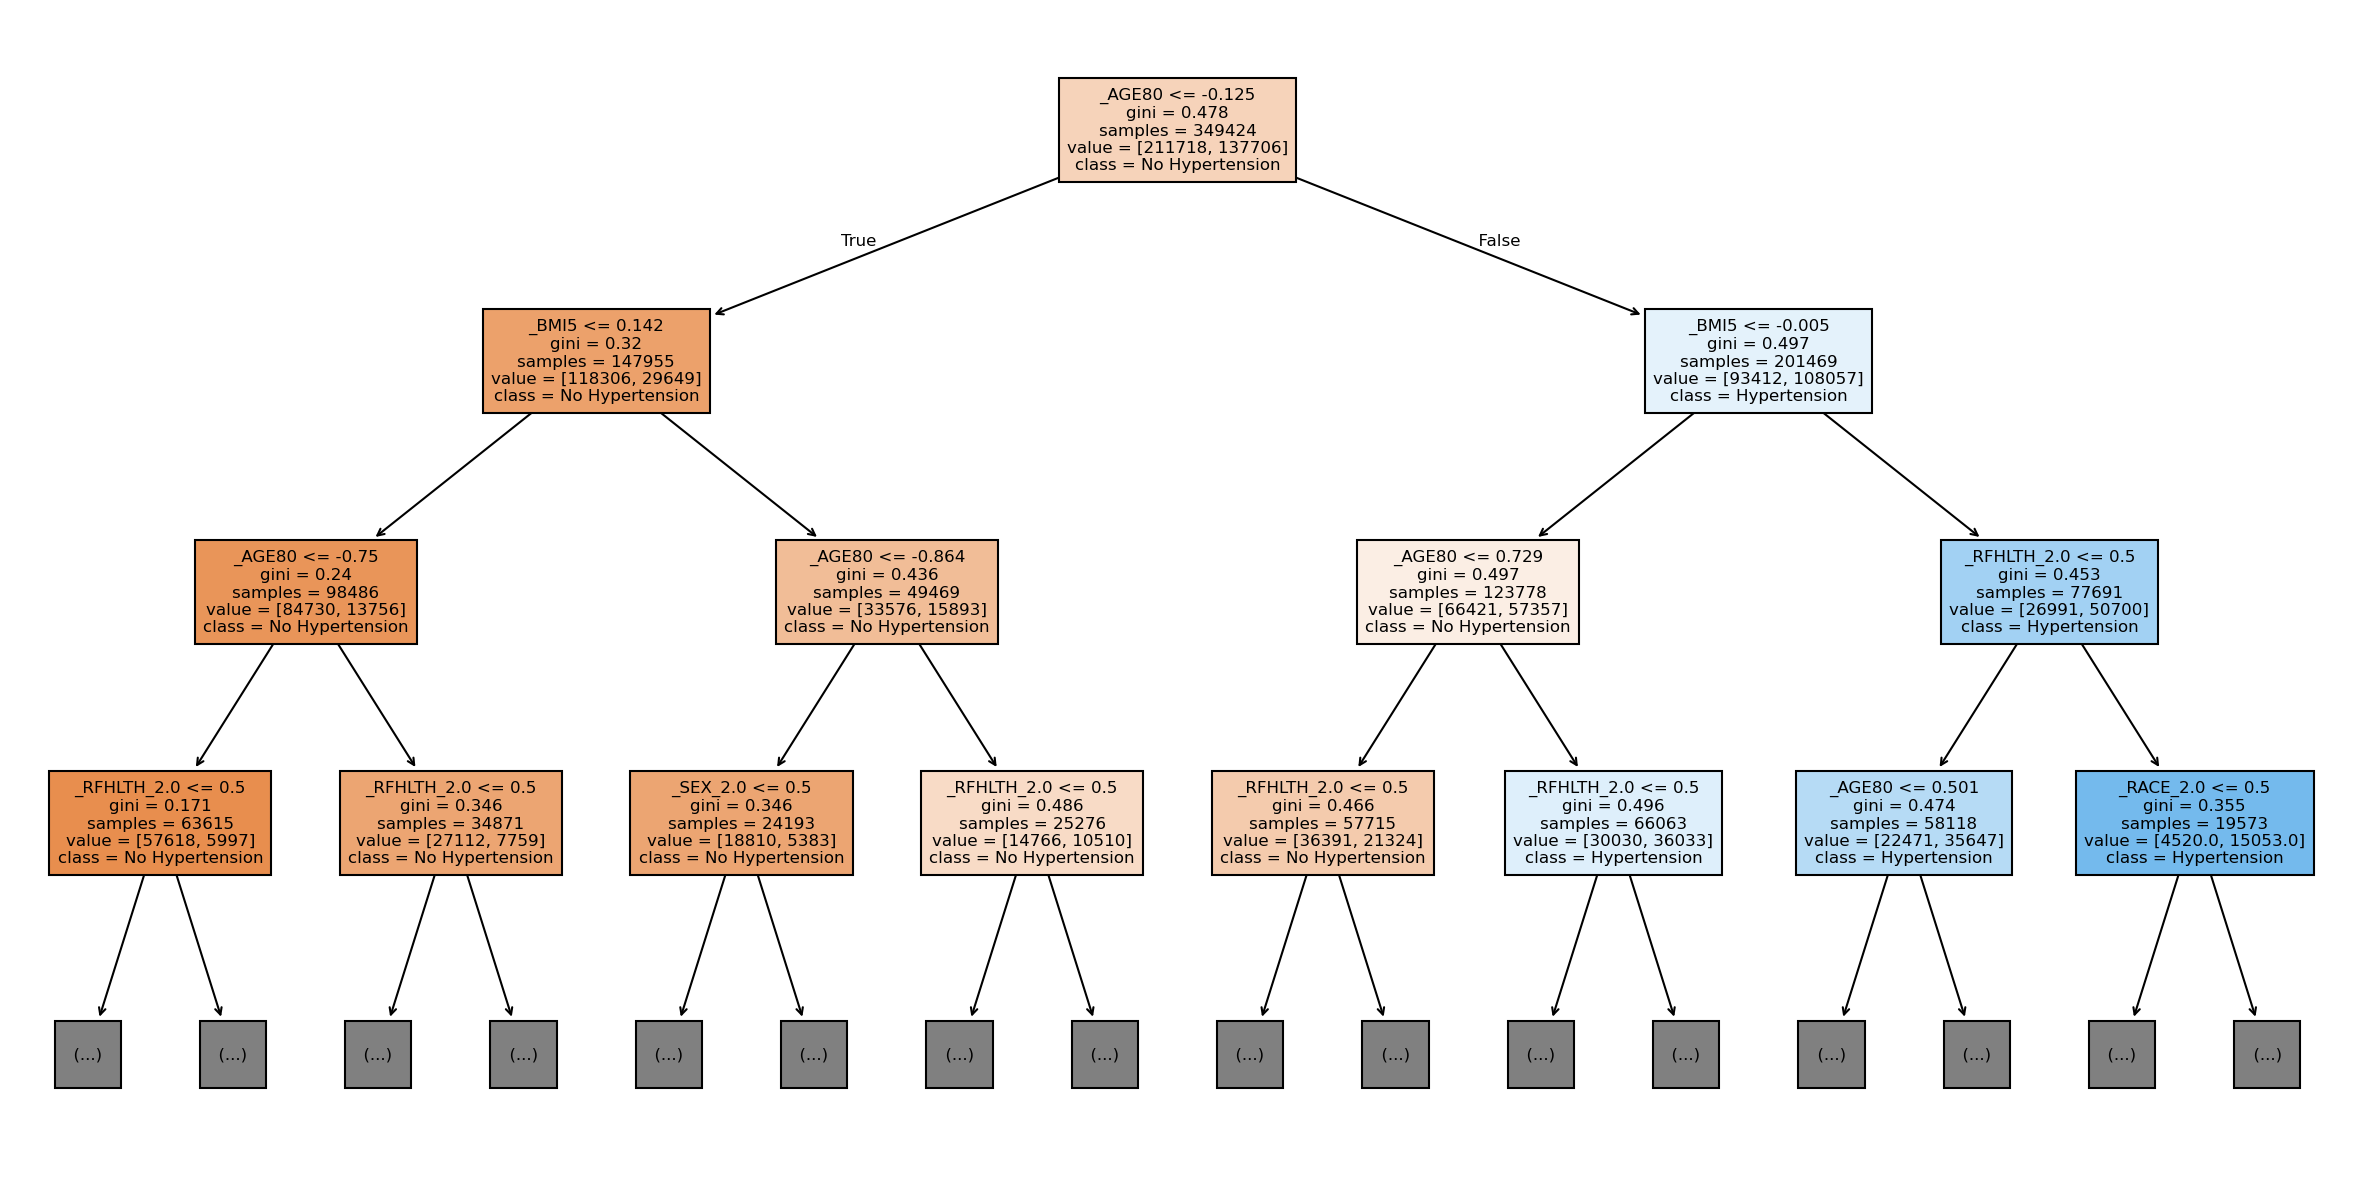

In [125]:
#Plot a restricted version of the Decision tree 
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    max_depth=3,
    feature_names=X_train.columns,
    class_names=['No Hypertension','Hypertension'],
    filled=True,
    fontsize=8
)

plt.show()

Observations from the baseline untuned decision tree model: 

1. Accuracy - Only 63% of the respondents were classified correctly
2. Precision - When the model predicts hypertension, it is correct 53% of the time
3. Recall - The model identifies 54% if the people who actually have hypertension.
4. F1 Score - 54% balance between precision and recall
5. ROC-AUC - at around 62%

The baseline Decision Tree achieved a testing accuracy of 63.2% and an ROC-AUC of 0.615, performing substantially worse than the baseline Logistic Regression model across all evaluation metrics. While the Decision Tree achieved a near-perfect training accuracy of 99.9%, its considerably lower testing accuracy (63%) indicates severe overfitting. This suggests that the model memorized patterns specific to the training data rather than learning relationships that generalize to unseen observations. As a result, hyperparameter tuning will be performed to constrain tree complexity and improve generalization performance.

# 2.1 Tuned Decision Tree 

In [142]:
#Define the parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10]
}

In [144]:
#Create the GridSearch 
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [146]:
#Fit the GridSearch
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 15], 'min_samples_leaf': [5, 10],
                         'min_samples_split': [10, 20]},
             scoring='roc_auc', verbose=1)

In [147]:
#Get the best parameters 
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validated ROC-AUC:")
print(f"{grid_search.best_score_:.3f}")

Best Parameters:
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 10}

Best Cross-Validated ROC-AUC:
0.776


In [152]:
#Extract the best model 
best_dt = grid_search.best_estimator_

In [154]:
#Evaluate on the test data using the best model
y_pred_best_dt = best_dt.predict(X_test)

y_prob_best_dt = best_dt.predict_proba(X_test)[:,1]

In [156]:
#Evaluate the model
dt_tuned_accuracy = accuracy_score(y_test, y_pred_best_dt)
dt_tuned_precision = precision_score(y_test, y_pred_best_dt)
dt_tuned_recall = recall_score(y_test, y_pred_best_dt)
dt_tuned_f1 = f1_score(y_test, y_pred_best_dt)
dt_tuned_auc = roc_auc_score(y_test, y_prob_best_dt)

print(f"Accuracy : {dt_tuned_accuracy:.3f}")
print(f"Precision: {dt_tuned_precision:.3f}")
print(f"Recall   : {dt_tuned_recall:.3f}")
print(f"F1 Score : {dt_tuned_f1:.3f}")
print(f"ROC-AUC  : {dt_tuned_auc:.3f}")

Accuracy : 0.716
Precision: 0.648
Recall   : 0.614
F1 Score : 0.630
ROC-AUC  : 0.779


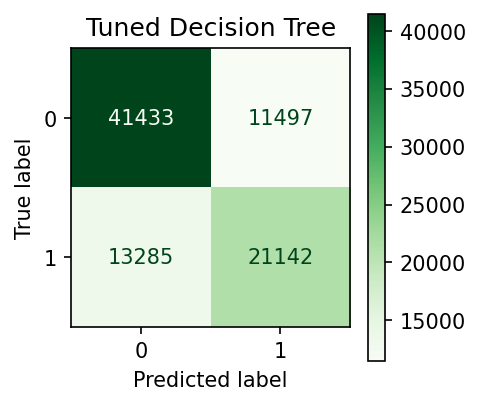

In [168]:
#Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best_dt,
    cmap="Greens"
)

plt.title("Tuned Decision Tree")
plt.show()

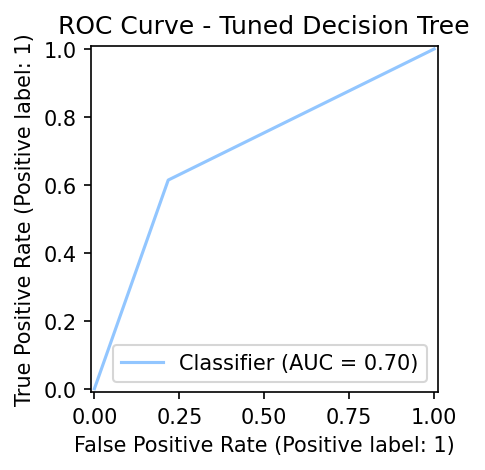

In [170]:
#Plot the ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    y_pred_best_dt
)

plt.title("ROC Curve - Tuned Decision Tree")
plt.show()

In [158]:
#Measure the extent of overfitting by looking at the accuracy of training and testing
train_pred_best = best_dt.predict(X_train)

train_accuracy_best = accuracy_score(y_train, train_pred_best)

print(f"Training Accuracy: {train_accuracy_best:.3f}")
print(f"Testing Accuracy : {dt_tuned_accuracy:.3f}")

Training Accuracy: 0.722
Testing Accuracy : 0.716


Observations from the baseline tuned Decision Tree model: 

1. Accuracy - 72% of the respondents were classified correctly
2. Precision - When the model predicts hypertension, it is correct 65% of the time
3. Recall - The model identifies 61% if the people who actually have hypertension.
4. F1 Score - 63% balance between precision and recall
5. ROC-AUC - at around 78%

Compared with the untuned model, the tuned Decision Tree increased testing accuracy from 63.2% to 71.6% while reducing the gap between training and testing accuracy from 36.7 percentage points to 0.6 percentage points, indicating that overfitting had been effectively controlled.

The tuned Decision Tree performed comparably to the baseline Logistic Regression model across most evaluation metrics. Although Logistic Regression maintained slightly higher accuracy (72.0% vs. 71.6%), precision (66.2% vs. 64.8%), and ROC-AUC (0.786 vs. 0.779), the tuned Decision Tree achieved a higher recall (61.4% vs. 59.0%). In the context of healthcare, improved recall may be advantageous because it increases the proportion of individuals with hypertension who are correctly identified for potential follow-up or intervention.

Although hyperparameter tuning substantially improved the performance of the Decision Tree model, a single decision tree can still be sensitive to small changes in the training data. Random Forest addresses this limitation by constructing an ensemble of decision trees using bootstrap sampling and random feature selection. The final prediction is based on the majority vote across all trees, which generally reduces model variance, improves generalization, and produces more robust predictions.

# 3.0 Baseline Random Forest

In [179]:
#Initiate the baseline Random Forest model
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [183]:
#Class predictions
y_pred_rf = rf.predict(X_test)

#Predicted probabilities
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [184]:
#Evaluate the model 
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy : {rf_accuracy:.3f}")
print(f"Precision: {rf_precision:.3f}")
print(f"Recall   : {rf_recall:.3f}")
print(f"F1 Score : {rf_f1:.3f}")
print(f"ROC-AUC  : {rf_auc:.3f}")

Accuracy : 0.715
Precision: 0.650
Recall   : 0.597
F1 Score : 0.623
ROC-AUC  : 0.779


In [187]:
#Print the classification report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.75      0.79      0.77     52930
           1       0.65      0.60      0.62     34427

    accuracy                           0.71     87357
   macro avg       0.70      0.69      0.70     87357
weighted avg       0.71      0.71      0.71     87357



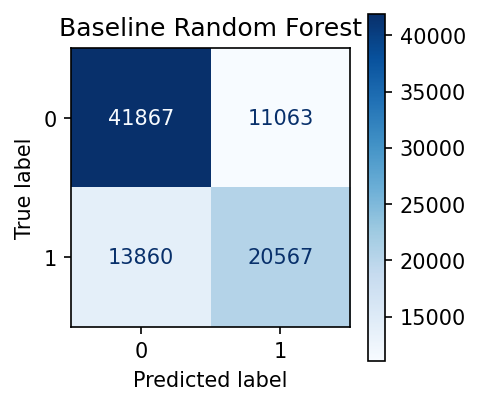

In [258]:
#Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues"
)

plt.title("Baseline Random Forest")
plt.show()

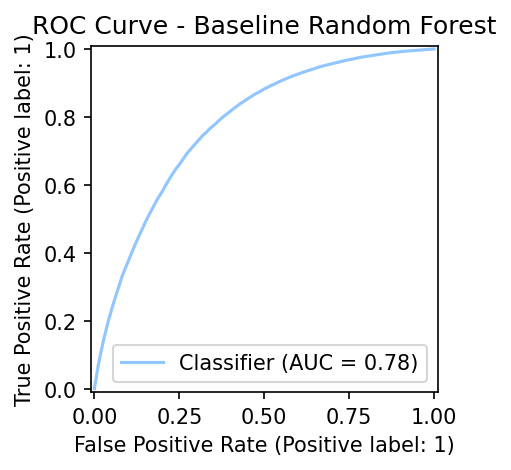

In [193]:
#Plot the ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title("ROC Curve - Baseline Random Forest")
plt.show()

In [195]:
#Measure the extent of overfitting by looking at the accuracy of training and testing
train_pred_rf = rf.predict(X_train)

train_accuracy_rf = accuracy_score(y_train, train_pred_rf)

print(f"Training Accuracy: {train_accuracy_rf:.3f}")
print(f"Testing Accuracy : {rf_accuracy:.3f}")

Training Accuracy: 0.999
Testing Accuracy : 0.715


Observations from the baseline Random Forest Model: 

1. Accuracy - 72% of the respondents were classified correctly
2. Precision - When the model predicts hypertension, it is correct 65% of the time
3. Recall - The model identifies 60% if the people who actually have hypertension.
4. F1 Score - 62% balance between precision and recall
5. ROC-AUC - at around 78%

The baseline Random Forest achieved a testing accuracy of 71.5% and an ROC-AUC of 0.779, performing comparably to the tuned Decision Tree but not surpassing the Logistic Regression model. In addition, the near-perfect training accuracy (99.9%) compared with the testing accuracy (71.5%) indicates that the default model remains substantially overfit. As a result, we will be performing hyperparameter tuning to constrain model complexity and improve predictive performance on testing data. 

RandomizedSearchCV was selected for hyperparameter tuning of the Random Forest model because the parameter space is substantially larger than that of the Decision Tree. Unlike GridSearchCV, which evaluates every possible parameter combination, RandomizedSearchCV samples a specified number of combinations from predefined distributions. This significantly reduces computational time while often producing comparable model performance.

# 3.0 Tuned Random Forest

In [223]:
#Define the parameter grid
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10],
    'max_features': ['sqrt']
}

In [225]:
#Create the RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid_rf,
    n_iter=10,          # Try only 10 combinations
    scoring='roc_auc',
    cv=3,  #Doing 3 instead of 5 because computational time is too long 
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [227]:
#Fit the RandomizedSearchCV
rf_random.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 20],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [5, 10],
                                        'min_samples_split': [10, 20],
                                        'n_estimators': [50, 100]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [231]:
#Get the best parameters
print("Best Parameters:")
print(rf_random.best_params_)

print("\nBest Cross-Validated ROC-AUC:")
print(f"{rf_random.best_score_:.3f}")

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 20}

Best Cross-Validated ROC-AUC:
0.787


In [235]:
#Extract the best model
best_rf = rf_random.best_estimator_

In [237]:
#Evaluate on the test data using the best model
y_pred_best_rf = best_rf.predict(X_test)

y_prob_best_rf = best_rf.predict_proba(X_test)[:,1]

In [238]:
#Evaluate the model
rf_tuned_accuracy = accuracy_score(y_test, y_pred_best_rf)
rf_tuned_precision = precision_score(y_test, y_pred_best_rf)
rf_tuned_recall = recall_score(y_test, y_pred_best_rf)
rf_tuned_f1 = f1_score(y_test, y_pred_best_rf)
rf_tuned_auc = roc_auc_score(y_test, y_prob_best_rf)

print(f"Accuracy : {rf_tuned_accuracy:.3f}")
print(f"Precision: {rf_tuned_precision:.3f}")
print(f"Recall   : {rf_tuned_recall:.3f}")
print(f"F1 Score : {rf_tuned_f1:.3f}")
print(f"ROC-AUC  : {rf_tuned_auc:.3f}")

Accuracy : 0.723
Precision: 0.661
Recall   : 0.609
F1 Score : 0.634
ROC-AUC  : 0.789


In [241]:
#Print the classification report
print(classification_report(y_test, y_pred_best_rf))

              precision    recall  f1-score   support

           0       0.76      0.80      0.78     52930
           1       0.66      0.61      0.63     34427

    accuracy                           0.72     87357
   macro avg       0.71      0.70      0.71     87357
weighted avg       0.72      0.72      0.72     87357



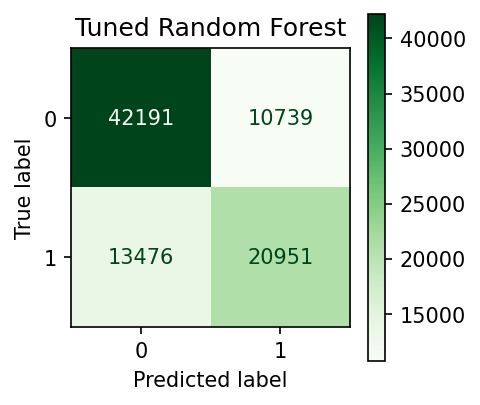

In [261]:
#Print the classification report
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best_rf,
    cmap="Greens"
)

plt.title("Tuned Random Forest")
plt.show()

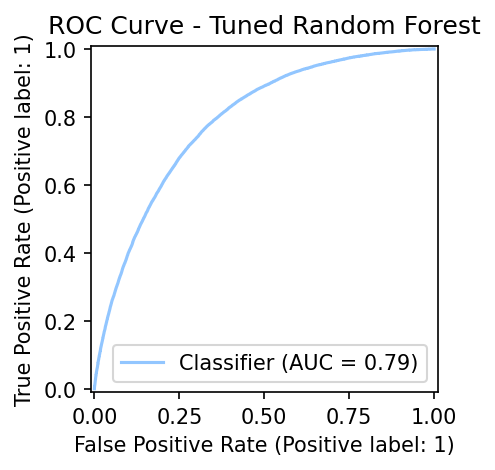

In [245]:
#Plot the ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_best_rf
)

plt.title("ROC Curve - Tuned Random Forest")
plt.show()

In [247]:
#Measure the extent of overfitting by looking at the accuracy of training and testing
train_pred_best_rf = best_rf.predict(X_train)

train_accuracy_best_rf = accuracy_score(
    y_train,
    train_pred_best_rf
)

print(f"Training Accuracy: {train_accuracy_best_rf:.3f}")
print(f"Testing Accuracy : {rf_tuned_accuracy:.3f}")

Training Accuracy: 0.760
Testing Accuracy : 0.723


In [251]:
#Save the best parameters 
best_rf_params = rf_random.best_params_

print(best_rf_params)

{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 20}


Observations from the baseline Random Forest Model:

1. Accuracy - 72% of the respondents were classified correctly
2. Precision - When the model predicts hypertension, it is correct 66% of the time
3. Recall - The model identifies 61% if the people who actually have hypertension.
4. F1 Score - 63% balance between precision and recall
5. ROC-AUC - at around 79%

Hyperparamter tuning greatly improved the Random Forest's ability to generalize by substantially reducing overfitting. The gap between training and testing accuracy decreased from 28.4 percentage points in the baseline model to 3.7 percentage points after tuning, while testing accuracy increased from 71.5% to 72.3%.

When we compare across all models, we find that the tuned Random Forest achieved the highest overall predictive performance with an accuracy of 72.3%, an F1-score of 63.4%, and a recall of 60.9%. Although the Logistic Regression model achieved a marginally higher ROC-AUC (0.786 versus 0.780), the difference was small, while the Random Forest demonstrated a better balance between identifying individuals with hypertension and minimizing false positives. These findings suggest that the tuned Random Forest provides the best overall trade-off between predictive performance and generalization for this dataset.

# Key Findings 

1. Hyperparameter tuning reduced overfitting substantially (training accuracy decreased from 99.9% to 76.0% while testing accuracy increased from 71.5% to 72.3%).
2. The tuned Random Forest achieved the highest overall predictive performance, with the best accuracy and F1-score among the evaluated models.
Logistic Regression remained highly competitive, achieving the highest ROC-AUC (0.786), suggesting that many relationships between the predictors and hypertension are approximately linear.
3. The tuned Random Forest will be used for feature importance analysis because it provides the best overall balance between predictive performance and generalization.